In [6]:
from datetime import datetime
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime
import os
from pathlib import Path
import fsspec

import re
pd.set_option('display.max_columns', None)
sys.path.insert(0, os.path.abspath('../..'))
import repo_paths  # noqa: F401
%load_ext autoreload
%autoreload 2
from loading_runs import load_results_from_pickle, compute_rowwise_metrics, plot_metric_vs_lambda

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import os

def drop_extreme_rows(df, lower=0.02, upper=0.98, ignore_cols=None):
    """
    Drop rows where any feature value lies outside [lower, upper] quantiles.
    
    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    lower : float
        Lower quantile (default=0.02).
    upper : float
        Upper quantile (default=0.98).
    ignore_cols : list, optional
        List of column names to ignore when filtering.
    
    Returns
    -------
    pd.DataFrame
        Filtered dataframe with ignored columns untouched.
    """
    if ignore_cols is None:
        ignore_cols = []

    # Only apply filtering to numeric, non-ignored columns
    cols = [c for c in df.columns if c not in ignore_cols and pd.api.types.is_numeric_dtype(df[c])]
    
    lower_bounds = df[cols].quantile(lower)
    upper_bounds = df[cols].quantile(upper)
    
    mask = ((df[cols] >= lower_bounds) & (df[cols] <= upper_bounds)).all(axis=1)
    return df[mask]


path = 'df.csv'
df = pd.read_csv(path)

print(len(df))
# Apply legacy filtering before model pipeline.
df = df[df['houseage'] < 50]
df = drop_extreme_rows(df, lower=0.01, upper=1, ignore_cols=['latitude', 'longitude'])
df = drop_extreme_rows(df, lower=0, upper=0.97, ignore_cols=['houseage', 'latitude', 'longitude'])
print(len(df))


20640
16036


In [8]:
df.drop('latitude',axis=1).corr().round(2)

,medinc,houseage,averooms,avebedrms,population,aveoccup,longitude
medinc,1.00,-0.15,0.68,-0.26,-0.02,-0.08,-0.02
houseage,-0.15,1.00,-0.21,-0.11,-0.29,0.05,-0.01
averooms,0.68,-0.21,1.00,0.04,-0.09,0.01,-0.12
avebedrms,-0.26,-0.11,0.04,1.00,0.02,-0.11,-0.01
population,-0.02,-0.29,-0.09,0.02,1.00,0.19,0.09
aveoccup,-0.08,0.05,0.01,-0.11,0.19,1.00,0.16
longitude,-0.02,-0.01,-0.12,-0.01,0.09,0.16,1.00


In [4]:
def compute_rowwise_metrics(row, just_f1=True, bin_mask_column='binary_mask'):
    g = np.array(row['g_test'])        # shape (n, p)
    pred = np.array(row[bin_mask_column])
    
    # True Positives, False Positives, False Negatives per row
    TP = np.sum((pred == 1) & (g == 1), axis=1)
    FP = np.sum((pred == 1) & (g == 0), axis=1)
    FN = np.sum((pred == 0) & (g == 1), axis=1)
    
    # Compute metrics per row
    TPR = TP / (TP + FN + 1e-10)
    FDR = FP / (TP + FP + 1e-10)
    F1  = 2 * TP / (2 * TP + FP + FN + 1e-10)
    
    # Take mean across all rows in this experiment
    if just_f1 == True:
        return pd.Series({
                'F1' : np.mean(F1)
            })
    else:
        return pd.Series({
                'TPR': np.mean(TPR),
                'FDR': np.mean(FDR),
                'F1' : np.mean(F1)
            })

## shap grid search

In [5]:
shap = load_results_from_pickle(folder='ICML_experiments/california_tests/val/xgb_grid',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['lmbda','accuracy', 'roc_auc', 'pct_sig'],
                                is_synthetic=False
                                        )#'after_hadi_conversation3')# #"%y_%m_%d_%H_%M_%S"

shap['F1'] = shap.apply(compute_rowwise_metrics, axis=1)


In [226]:
shap['config_tuple'] = shap['xgb_params'].apply(lambda x: tuple(sorted(x.items())))
shap['config_id'] = shap['config_tuple'].factorize()[0]
cols_shap_num = ['TPR_mean','FDR_mean','f1','roc_auc','pr_auc']
for i in cols_shap_num:
    shap[i] = shap[i].astype(float)

In [227]:
shap.groupby('config_id')[cols_shap_num].mean().sort_values(by='roc_auc',ascending=False)

,TPR_mean,FDR_mean,f1,roc_auc,pr_auc
config_id,,,,,
25,74.355777,25.644223,74.355777,0.999629,0.999543
26,77.140482,22.859518,77.140482,0.999376,0.999229
23,75.623441,24.376559,75.623441,0.999261,0.999068
17,76.704073,23.295927,76.704073,0.999040,0.998796
22,70.739817,29.260183,70.739817,0.998810,0.998409
14,72.817955,27.182045,72.817955,0.998417,0.998000
20,74.210307,25.789692,74.210308,0.997893,0.997300
19,65.814630,34.185370,65.814630,0.997453,0.996349
16,70.511222,29.488778,70.511222,0.997383,0.996661


choose by highest roc_auc. other values are unknown

In [228]:
shap.query('config_id==25').iloc[0].xgb_params

{'max_depth': 7,
 'eta': 0.2,
 'colsample_bytree': 0.8,
 'objective': 'binary:logistic',
 'eval_metric': 'logloss',
 'seed': 10,
 'num_boost_round': 100}

## load val for invase, realx, hide&seek

In [9]:
others = load_results_from_pickle(folder='ICML_experiments/california_tests/val',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['lmbda','accuracy', 'TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig'],
                                is_synthetic=False
                                        )

assert (others.num_important_features == 3).all()
assert (others['mask'].apply(lambda x: x.shape[1])==7).all()
others['F1'] = others.apply(compute_rowwise_metrics, axis=1)

## hide_and_seek_search

In [10]:
temp = others.copy().query('model=="Hide&Seek"')

In [11]:
temp.groupby(['model','lmbda'])[['TPR_mean','FDR_mean','f1']].count()

TPR_mean  FDR_mean  f1
model     lmbda                        
Hide&Seek 0.00          1         1   1
          0.05          1         1   1
          0.10          1         1   1
          0.25          1         1   1
          0.50          1         1   1
          0.75          1         1   1
          1.00          1         1   1
          1.25          1         1   1
          1.50          1         1   1

In [12]:
a = temp.groupby(['model','lmbda'])[['TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']].mean().sort_values(by='roc_auc',ascending=False).reset_index()
a[['lmbda','roc_auc','pr_auc','pct_sig']]

,lmbda,roc_auc,pr_auc,pct_sig
0,0.10,0.982729,0.979479,0.799341
1,0.05,0.982289,0.978856,0.875401
2,0.00,0.981849,0.978153,0.937834
3,0.25,0.977139,0.971946,0.582651
4,0.50,0.976391,0.969948,0.542394
5,0.75,0.952923,0.942636,0.364179
6,1.00,0.951731,0.939255,0.342982
7,1.25,0.946526,0.932492,0.332205
8,1.50,0.940855,0.924955,0.320983


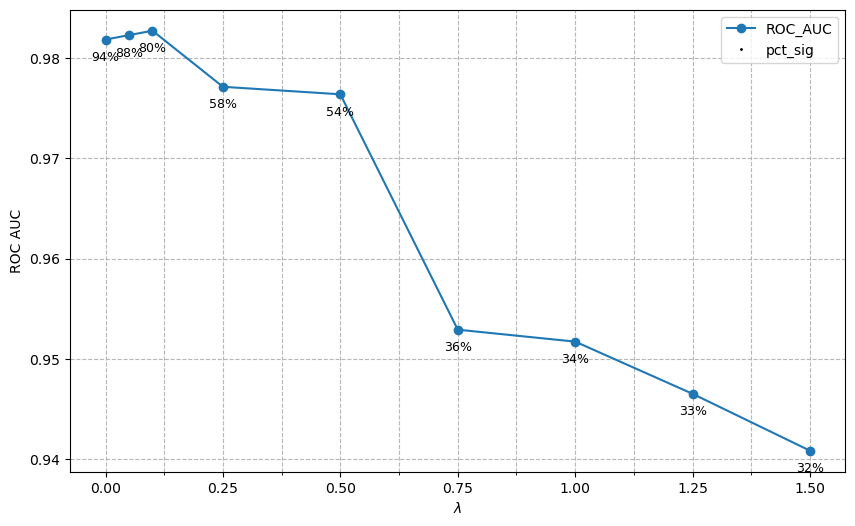

In [233]:
a_sorted = a.sort_values('lmbda')
# Call 1: Sets up the base plot (left y-axis), returns the axis
my_ax = plot_metric_vs_lambda(a_sorted,
                              groupby_cols=None,
                              query='lmbda<5',
                              metric_col='roc_auc',
                              annotate_sig=True,
                             x_ticks=(0,1.75,0.25))

plt.show()

- don't get fooled by the three close together. Consider them one value
- $\lambda=0.5$ seems clearly to be the best before dropoff
- ground truth shown below for interest, after $\lambda$ choice

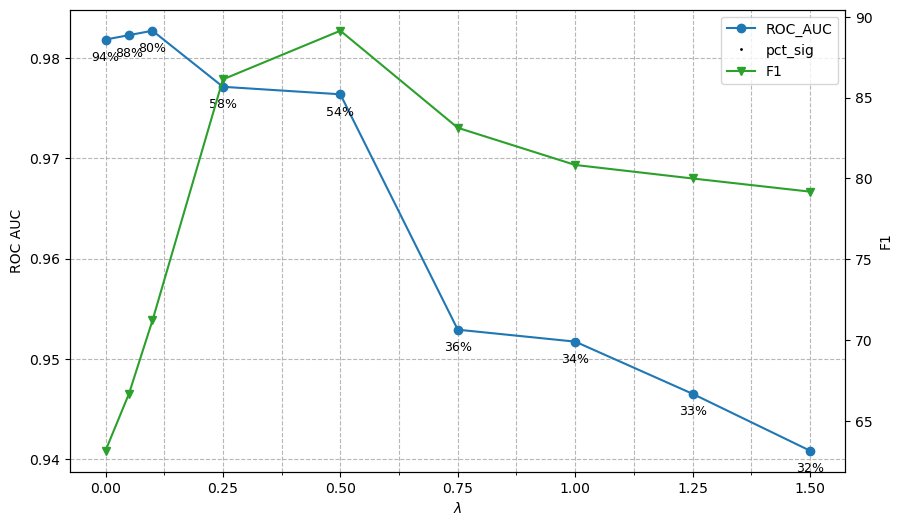

In [234]:
a_sorted = a.sort_values('lmbda')
# Call 1: Sets up the base plot (left y-axis), returns the axis
my_ax = plot_metric_vs_lambda(a_sorted,
                              groupby_cols=None,
                              query='lmbda<5',
                              metric_col='roc_auc',
                              annotate_sig=True,
                             x_ticks=(0,1.75,0.25))

# Call 2: Uses the existing axis, declares itself a twin (right y-axis)
plot_metric_vs_lambda(a_sorted,
                      groupby_cols=None,
                      query='lmbda<5',
                      metric_col='f1',
                      ax=my_ax,
                      annotate_sig=False,
                      is_twin=True,
                     x_ticks=(0,1.75,0.25))

plt.show()

- we love Hide&Seek

## realx search

In [239]:
temp = others.copy().query('model=="REAL-x"')

In [240]:
temp.groupby(['model','lmbda'])[['TPR_mean','FDR_mean','f1']].count()

TPR_mean  FDR_mean  f1
model  lmbda                        
REAL-x 0.00          1         1   1
       0.05          1         1   1
       0.10          1         1   1
       0.25          1         1   1
       0.50          1         1   1
       0.75          1         1   1
       1.00          1         1   1
       1.25          1         1   1
       1.50          1         1   1

In [241]:
a = temp.groupby(['model','lmbda'])[['TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']].mean().sort_values(by='roc_auc',ascending=False).reset_index()
a[['lmbda','roc_auc','pr_auc','pct_sig']]

,lmbda,roc_auc,pr_auc,pct_sig
0,0.00,0.931540,0.916177,0.774136
1,0.05,0.929172,0.913809,0.425009
2,0.10,0.925465,0.898855,0.399181
3,1.00,0.887235,0.847321,0.065372
4,0.25,0.878695,0.841009,0.235928
5,0.50,0.859029,0.808054,0.195761
6,1.25,0.840477,0.775606,0.036516
7,1.50,0.823025,0.724293,0.047738
8,0.75,0.774726,0.700715,0.077841


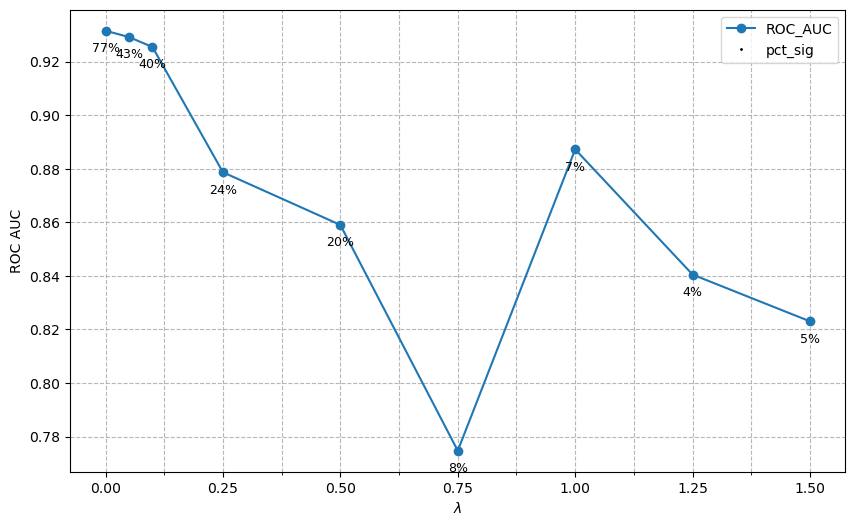

In [242]:
a_sorted = a.sort_values('lmbda')
# Call 1: Sets up the base plot (left y-axis), returns the axis
my_ax = plot_metric_vs_lambda(a_sorted,
                              groupby_cols=None,
                              query='lmbda<5',
                              metric_col='roc_auc',
                              annotate_sig=True,
                             x_ticks=(0,1.75,0.25))

plt.show()

- harder to decide. similar initial grouping to Hide&Seek initially, but the percentage sig is dropping much faster. This is why we ran on those values - we thought REAL-x might need it. 25% won't be enough features (we're using some background knowledge here. We do know 40-45% are important...)
- seems fair to choose the 40% before big drop off. Could be an argument for 43% as well, but it's too close to that 77%
- choosing $\lambda=0.1$, corresponding to the 40%
- ground truth shown below for interest, after $\lambda$ choice

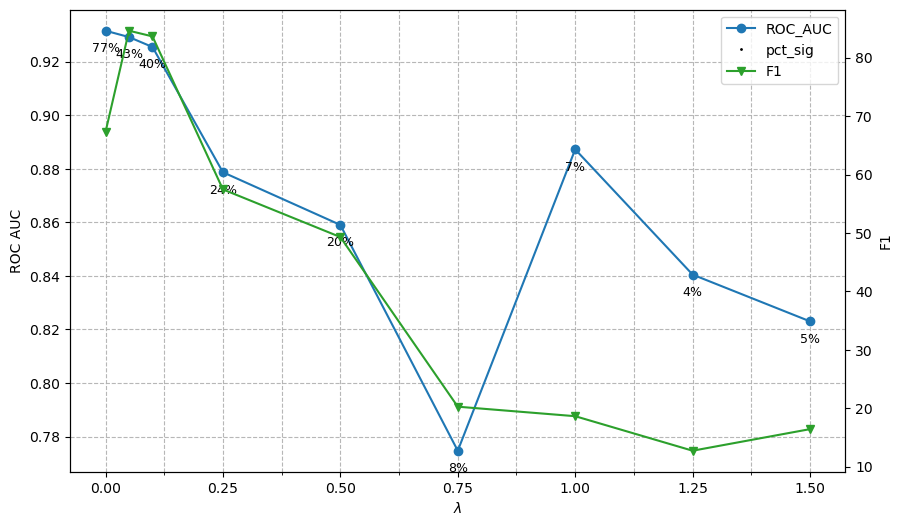

In [243]:
a_sorted = a.sort_values('lmbda')
# Call 1: Sets up the base plot (left y-axis), returns the axis
my_ax = plot_metric_vs_lambda(a_sorted,
                              groupby_cols=None,
                              query='lmbda<5',
                              metric_col='roc_auc',
                              annotate_sig=True,
                             x_ticks=(0,1.75,0.25))

# Call 2: Uses the existing axis, declares itself a twin (right y-axis)
plot_metric_vs_lambda(a_sorted,
                      groupby_cols=None,
                      query='lmbda<5',
                      metric_col='f1',
                      ax=my_ax,
                      annotate_sig=False,
                      is_twin=True,
                     x_ticks=(0,1.75,0.25))

plt.show()

- fair call

# invase_search

In [244]:
temp = others.copy().query('model=="INVASE"')

In [245]:
temp.groupby(['model','lmbda'])[['TPR_mean','FDR_mean','f1']].count()

TPR_mean  FDR_mean  f1
model  lmbda                        
INVASE 0.00          1         1   1
       0.05          1         1   1
       0.10          1         1   1
       0.25          1         1   1
       0.50          1         1   1
       0.75          1         1   1
       1.00          1         1   1
       1.25          1         1   1
       1.50          1         1   1

In [246]:
a = temp.groupby(['model','lmbda'])[['TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']].mean().sort_values(by='roc_auc',ascending=False).reset_index()
a[['lmbda','roc_auc','pr_auc','pct_sig']]

,lmbda,roc_auc,pr_auc,pct_sig
0,1.00,0.979212,0.976436,0.055130
1,0.05,0.979064,0.976736,0.443445
2,0.25,0.978717,0.976064,0.245636
3,0.50,0.978618,0.975181,0.083897
4,1.25,0.978412,0.975576,0.046046
5,1.50,0.977057,0.974057,0.029747
6,0.10,0.977057,0.974337,0.338885
7,0.00,0.974046,0.969500,0.491984
8,0.75,0.972713,0.969323,0.066797


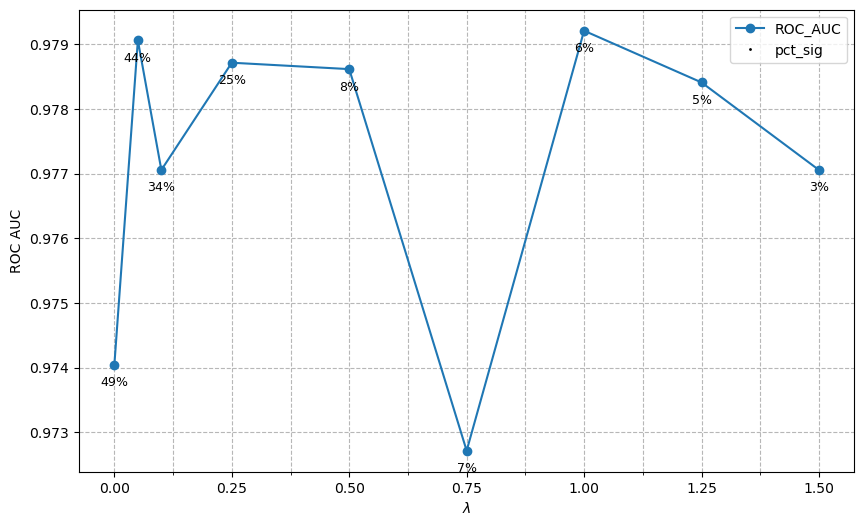

In [247]:
a_sorted = a.sort_values('lmbda')
# Call 1: Sets up the base plot (left y-axis), returns the axis
my_ax = plot_metric_vs_lambda(a_sorted,
                              groupby_cols=None,
                              query='lmbda<5',
                              metric_col='roc_auc',
                              annotate_sig=True,
                             x_ticks=(0,1.75,0.25))

plt.show()

- Difficult. Looks to be 8% (0.5) but we know that's too low
- similarly to REAL-x, we use a bit of background knowledge (40-45%)
- We choose $\lambda=0.05$, corresponding to the 44%
- ground truth shown below for interest, after $\lambda$ choice

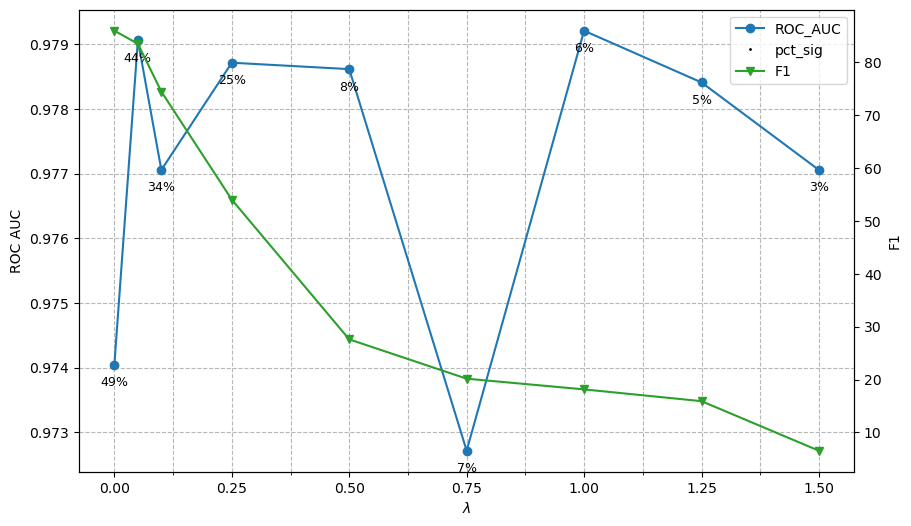

In [248]:
a_sorted = a.sort_values('lmbda')
# Call 1: Sets up the base plot (left y-axis), returns the axis
my_ax = plot_metric_vs_lambda(a_sorted,
                              groupby_cols=None,
                              query='lmbda<5',
                              metric_col='roc_auc',
                              annotate_sig=True,
                             x_ticks=(0,1.75,0.25))

# Call 2: Uses the existing axis, declares itself a twin (right y-axis)
plot_metric_vs_lambda(a_sorted,
                      groupby_cols=None,
                      query='lmbda<5',
                      metric_col='f1',
                      ax=my_ax,
                      annotate_sig=False,
                      is_twin=True,
                     x_ticks=(0,1.75,0.25))

plt.show()

- validated

## comparing

each model has been run 10 times on different seeds, on the test data, using the optimal params (where tuning was an option) found above on the val data

In [10]:
temp = load_results_from_pickle(folder='ICML_experiments/california_tests/test',
                                        time_threshold='25_09_03_12_00_00',
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['TPR_mean','FDR_mean','f1','lmbda','accuracy', 'roc_auc', 'pct_sig'],
                                is_synthetic=False
                                        )

temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)
assert (temp.num_important_features==3).all()

In [250]:
temp.groupby(['model','lmbda'])[['TPR_mean','FDR_mean','f1']].count()

,,TPR_mean,FDR_mean,f1
model,lmbda,,,
Hide&Seek,0.50,10,10,10
INVASE,0.05,10,10,10
L2X,0.30,10,10,10
LIME,0.30,10,10,10
REAL-x,0.10,10,10,10
SHAP,0.06,10,10,10


- for the 10 seeds
- lmbda for L2X, LIME and SHAP is irrelevant. ignore

In [251]:
temp.seed.value_counts()

0    6
1    6
2    6
3    6
4    6
5    6
6    6
7    6
8    6
9    6
Name: seed, dtype: int64

In [252]:
independent_medians = temp.groupby(['model','lmbda'])[['TPR_mean','FDR_mean','f1']].median()
independent_medians.round(0)

,,TPR_mean,FDR_mean,f1
model,lmbda,,,
Hide&Seek,0.50,97.0,17.0,88.0
INVASE,0.05,84.0,17.0,83.0
L2X,0.30,52.0,48.0,52.0
LIME,0.30,56.0,44.0,56.0
REAL-x,0.10,79.0,10.0,83.0
SHAP,0.06,74.0,26.0,74.0


In [253]:
print(independent_medians)

                  TPR_mean   FDR_mean         f1
model     lmbda                                 
Hide&Seek 0.50   97.111388  17.292335  88.350404
INVASE    0.05   83.884040  16.689007  82.623278
L2X       0.30   51.963840  48.036159  51.963840
LIME      0.30   55.891521  44.108479  55.891521
REAL-x    0.10   78.990025   9.997402  82.850908
SHAP      0.06   74.376558  25.623441  74.376559


In [254]:
model_order = ['Hide&Seek', 'INVASE', 'REAL-x', 'SHAP', 'LIME', 'L2X']

to_print = (
    independent_medians
    .reset_index(level='lmbda', drop=True)             
    .rename(columns=lambda x: x.replace('_mean', ''))  
    .rename(columns={'f1': 'F1'})                      
    .reindex(model_order)                              
    .round(0)                                          
    .astype('Int64')                                   
)

print(to_print.T)

model  Hide&Seek  INVASE  REAL-x  SHAP  LIME  L2X
TPR           97      84      79    74    56   52
FDR           17      17      10    26    44   48
F1            88      83      83    74    56   52


In [255]:
latex_code = to_print.T.style.to_latex()
print(latex_code)

\begin{tabular}{lrrrrrr}
model & Hide&Seek & INVASE & REAL-x & SHAP & LIME & L2X \\
TPR & 97 & 84 & 79 & 74 & 56 & 52 \\
FDR & 17 & 17 & 10 & 26 & 44 & 48 \\
F1 & 88 & 83 & 83 & 74 & 56 & 52 \\
\end{tabular}

